In [1]:
# Load libraries
import pandas as pd
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
import statsmodels.api as sm

sns.set_style('darkgrid')
import math
from sklearn.linear_model import LogisticRegression
from scipy import stats

import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

from license_model import LicenseModel

## 1. Setup Model

The LicenseModel class holds most of the data pertaining to our analysis. Most importantly, it has the attribute 'listings_df'. This dataframe contains the city listings information and associated key variables for completing our model.

In [2]:
# INPUT VARIABLES

CITY = 'Barcelona'
INPUT_FILE = os.path.join('data', 'barcelona_listings.csv')
MIN_NIGHTS_FOR_LICENSE = 29
LICENSE_REGEX_PATTERN = r'^[Hh][Uu][Tt][Bb][-]?\d{6}$' # for Barcelona
# LICENSE_REGEX_PATTERN = r'^[Pp][Ii][Dd][-]?[Ss][Tt][Rr][Aa][-]?\d{1,6}[-]?\d{0,6}$' # for Sydney
# LICENSE_REGEX_PATTERN = r'\d{13}'  # for Paris
# LICENSE_REGEX_PATTERN = r'\d{11}'  # for Athens

In [3]:
city_model = LicenseModel(
    input_file=INPUT_FILE,
    city=CITY,
    min_nights_for_license=MIN_NIGHTS_FOR_LICENSE,
    license_regex_pattern=LICENSE_REGEX_PATTERN
)

city_model.run_initial_setup(print_info=False)

The run_initial_setup() method runs a collection of initialization methods in the correct order. You may also wish to run each method individually (either for testing purposes or to try the various settings). These are the methods being run and their appropriate order:

```Python
    city_model.load_data()
    city_model.preprocess_data(print_info=False)
    city_model.create_legal_listing_column(print_info=False)
    city_model.transform_object_columns()
    city_model.remove_low_variance_columns(print_info=False)
    city_model.remove_missing_values(print_info=False)
    city_model.one_hot_encode_columns(print_info=False)
    city_model.remove_separation(print_info=False)
    city_model.detect_and_remove_multicollinearity(print_info=False)
```

Note: Most of these methods have a parameter titled "print_info". If you set print_info to True, additional information will be printed regarding the results of each step.


## 2. Check Assumptions

### 2.1 Linearity of independent variables and log odds.

In [4]:
violating_vars = city_model.check_linearity_of_independent_variables_and_log_odds()
print("Significant variables (p < 0.05) that violate linearity assumption:")
print(violating_vars)


Significant variables (p < 0.05) that violate linearity assumption:
['accommodates', 'number_of_reviews_ly', 'calculated_host_listings_count']


##### Uh oh! Did the above test show that certain variables are violating the assumption? Using the code below you may be able to find a transformation that edits the variable in such a way that the assumption is no longer violated.

Note: If you are testing the same city in different time periods, it is vital to find the same transformation across the different files for each variable, or else the results won't be comparable.

### -- Important! Only apply transformations if the variable is important (such as Price). --

Modifying the variables in this way can lead to messed up model results. It is preferable to just delete the variables since we already have so many to test for anyways. 

In [5]:
delete_instead_of_transform = True  # Set to True if you want to delete the violating variables instead of transforming them

if delete_instead_of_transform:
    # If we are deleting the violating variables, we will remove them from the DataFrame
    for var in violating_vars:
        print(f"Deleting variable: {var}")
        city_model.listings_df.drop(columns=[var], inplace=True)
else:
    print("Transforming variables to resolve linearity issues...")

    # Test multiple transformations for each violating variable
    for var in violating_vars:
        print("_" * 50)
        # Make a clean copy of the original data
        listings_data_temp = city_model.listings_df.copy()

        print(f"Testing transformations for variable: {var}")

        # Define a list of transformations to try
        transformations = {
            "log": lambda x: np.log1p(x),  # log(1 + x), handles zero values
            "sqrt": lambda x: np.sqrt(x),  # square root
            "reciprocal": lambda x: 1 / (x + 1e-6),  # reciprocal, avoids division by zero
            "square": lambda x: x**2,  # square
            "cube": lambda x: x**3,  # cube
            "exp": lambda x: np.exp(x),  # exponential
            "inverse_sqrt": lambda x: 1 / (np.sqrt(x) + 1e-6),  # inverse square root
            "log10": lambda x: np.log10(x + 1e-6),  # base-10 logarithm
            "log2": lambda x: np.log2(x + 1e-6),  # base-2 logarithm
            "zscore": lambda x: (x - np.mean(x)) / np.std(x),  # z-score normalization
            "minmax": lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)),  # min-max scaling
            "sigmoid": lambda x: 1 / (1 + np.exp(-x)),  # sigmoid transformation
            "tanh": lambda x: np.tanh(x),  # hyperbolic tangent
            "arcsinh": lambda x: np.arcsinh(x),  # inverse hyperbolic sine
            "cbrt": lambda x: np.cbrt(x),  # cube root
            "abs": lambda x: np.abs(x),  # absolute value
            "clip": lambda x: np.clip(x, 0, np.percentile(x, 95)),  # clip outliers at 95th percentile
            "rank": lambda x: x.rank(method="average"),  # rank transformation
            "binarize": lambda x: (x > np.median(x)).astype(int),  # binarize based on median
        }

        # Try each transformation
        for name, transform in transformations.items():
            try:
                # Apply the transformation
                transformed_var = transform(listings_data_temp[var])
                listings_data_temp[var] = transformed_var

                # Re-check linearity with the transformed variable
                new_violating_vars = city_model.check_linearity_of_independent_variables_and_log_odds(
                    df_city_1=listings_data_temp
                )

                if var not in new_violating_vars:
                    print(f"Transformation '{name}' resolved linearity issue for {var}.")

                    # Update the model with the transformed variable
                    city_model.listings_df[f"{var}_{name}"] = transformed_var
                    city_model.listings_df.drop(columns=[var], inplace=True)
                    
                    break  # Stop testing further transformations for this variable
                else:
                    # print(f"Transformation '{name}' did not resolve linearity issue for {var}.")
                    pass
            except Exception as e:
                print(f"Error applying transformation '{name}' to {var}: {e}")

        else:
            # If no transformation resolved the issue
            print(f"No transformation resolved the linearity issue for {var}.")

Deleting variable: accommodates
Deleting variable: number_of_reviews_ly
Deleting variable: calculated_host_listings_count


### 2.2 No strongly influential outliers

Optimization terminated successfully.
         Current function value: 0.300226
         Iterations: 439
         Function evaluations: 447
         Gradient evaluations: 443
Threshold for Cook Distance = 0.0003468007629616785
Number of influential outliers: 281
Percentage of influential outliers: 2.4%


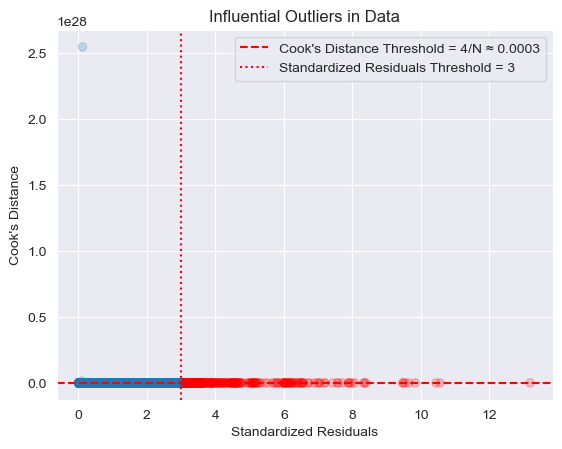

In [6]:
city_model.check_no_strongly_influential_outliers(print_info=True, show_plot=True, remove_hi_outliers=True)

## 3. Run LOGIT Model

Nice! Now we get to test and run the model.

In [7]:
city_model.train_model()

Optimization terminated successfully.
         Current function value: 0.215452
         Iterations: 438
         Function evaluations: 445
         Gradient evaluations: 442
                           Logit Regression Results                           
Dep. Variable:          legal_listing   No. Observations:                 9002
Model:                          Logit   Df Residuals:                     8926
Method:                           MLE   Df Model:                           75
Date:                Wed, 28 May 2025   Pseudo R-squ.:                  0.6864
Time:                        21:55:30   Log-Likelihood:                -1939.5
converged:                       True   LL-Null:                       -6184.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

We can also evaluate the model results. You can modify the LOGIT threshold. We may want to modify this number if, for example, we want to prioritize true negatives (catching the most unlicensed listings).

In [8]:
city_model.evaluate_model(selected_threshold=0.5)

Accuracy: 0.8987
Confusion Matrix:
[[ 846  144]
 [  84 1177]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.85      0.88       990
         1.0       0.89      0.93      0.91      1261

    accuracy                           0.90      2251
   macro avg       0.90      0.89      0.90      2251
weighted avg       0.90      0.90      0.90      2251



The following method exemplifies how additional code can be easily added in to check how the model is doing. In this case, we use the one in ten rule to make sure there are enough samples points based on the number of variables included.

In [9]:
city_model.does_data_follow_one_in_ten_rule()

Number of events (legal/illegal listings): 4992
Maximum number of predictors allowed (one-in-ten rule): 499
Number of predictors in the model: 76
The model follows the one-in-ten rule.


True

#### Note: You are able to access the model directly (and thus test it in anyway you wish) by calling city_model.logit_model

For example, the following function runs directly off of the logit model and creates a ROC curve in order to test the results.

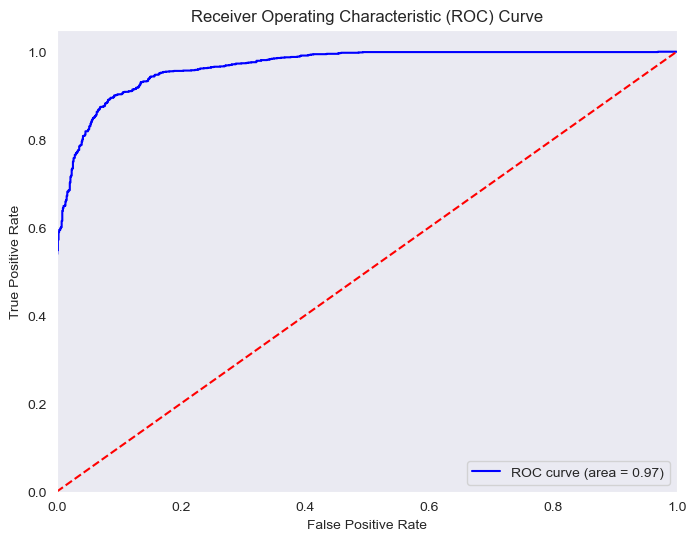

In [10]:
city_model.logit_model.create_roc_curve()

In [11]:
city_model.logit_model.find_threshold_where_fpr(target_fpr=0.25)

Selected threshold for FPR ≈ 0.25: 0.1632
Actual FPR: 0.2495, TPR: 0.9643


np.float64(0.16315861913199126)

We will later be using `city_model.logit_model` to extract the variable coefficients for further analysis.